In [1]:
# ==========================================
# Cell 1: 导入依赖、初始化配置与模型加载
# ==========================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pyomo.environ as pyo
import warnings
import tqdm

# 抑制不需要的警告
warnings.filterwarnings("ignore", category=UserWarning)
# (已移除引起报错的 Pyomo 警告抑制代码)

# 确保项目根目录在 sys.path 中 
project_root = Path.cwd().parent  # 确保这里和你的实际路径一致
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configs.default_config import Config
from envs.hems_env import EnergyStorageEnv
from madrl.maddpg import MADDPG

# ---------------- 配置测试参数 ----------------
TEST_START_DAY = 0        # 测试起始天数 (n)
TEST_DAYS = 20            # 连续测试的天数
LOAD_EPISODE = 992        # MADRL 模型代数 (请根据实际保存情况修改)
ALGORITHM = "MADDPG"      # MADRL 算法名称
MODEL_DIR = f"./saved_models/{ALGORITHM}" # 模型所在路径

# ---------------- 初始化 ----------------
args = Config()
args.algorithm = ALGORITHM
# 测试时无需探索
args.use_noise_decay = False 
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=> 初始化 MADRL 测试环境 (Mode: test)...")
# 测试时直接使用原始环境，便于指定 episode_idx
env = EnergyStorageEnv(args, mode='test')

# 补齐 Agent 维度参数
args.N = env.n
args.obs_dim_n = [env.observation_space[i].shape[0] for i in range(args.N)]
args.action_dim_n = [env.action_space[i].shape[0] for i in range(args.N)]

print("=> 加载训练好的 MADRL 模型...")
drl_agents = [MADDPG(args, i) for i in range(args.N)]
for agent in drl_agents:
    agent.load_model(MODEL_DIR, LOAD_EPISODE)

# ---------------- MPC 数据加载准备 ----------------
print("=> 准备 MPC 数据加载...")
# MPC 直接读取 CSV
mpc_data_path = project_root / "data" / "test_prices.csv"
df_mpc = pd.read_csv(mpc_data_path)
all_prices_mpc = df_mpc['price'].values
load_cols_mpc = [f'load{i+1}' for i in range(args.num_agents)]
if all([col in df_mpc.columns for col in load_cols_mpc]):
    all_loads_mpc = df_mpc[load_cols_mpc].values
else:
    # 兼容单列负荷的情况
    all_loads_mpc = np.repeat(df_mpc['load'].values[:, None], args.num_agents, axis=1)

print("✅ 所有加载完成。")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


=> 初始化 MADRL 测试环境 (Mode: test)...
=> 加载训练好的 MADRL 模型...
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
Agent 0: Models loaded successfully from episode 992.
Agent 1: Models loaded successfully from episode 992.
Agent 2: Models loaded successfully from episode 992.
=> 准备 MPC 数据加载...
✅ 所有加载完成。


In [2]:
# ==========================================
# Cell 2: 执行 DRL 和 MPC 测试，收集数据
# ==========================================
from tqdm.auto import tqdm

# ---------------- 用于保存两个方法的详细数据 ----------------
drl_test_results = []
mpc_test_results = []

# ==========================================
# 1. 执行 DRL 测试
# ==========================================
print(f"=> 开始执行 DRL 测试: Day {TEST_START_DAY} ~ {TEST_START_DAY + TEST_DAYS - 1}")
for day_idx in tqdm(range(TEST_START_DAY, TEST_START_DAY + TEST_DAYS), desc="DRL Evaluation"):
    obs_n = env.reset(episode_idx=day_idx)
    
    # 记录当天的临时数据 (含个体电力平衡数据)
    day_data = {
        'price': [], 'orig_load': [], 'net_load': [],
        'e_bat': {i: [] for i in range(args.N)},
        'soc': {i: [env.init_soc] for i in range(args.N)}, 
        'orig_load_agent': {i: [] for i in range(args.N)},
        'net_load_agent': {i: [] for i in range(args.N)},
        'daily_profit': 0.0,
        'pv_limit_penalty': {i: [] for i in range(args.N)} # 保留位置
    }
    
    for step in range(args.episode_limit):
        a_n = []
        # Zero Noise for Testing
        for i in range(args.N):
            obs_batch = np.expand_dims(obs_n[i], axis=0)
            a_batch = drl_agents[i].choose_action(obs_batch, noise_std=0.0)
            a_n.append(a_batch[0]) 
            
        obs_next_n, rewards, done_n, info = env.step(a_n)
        
        price = info['price']
        e_bat_arr = info['e_bat']        # shape: (N,)
        net_load_arr = info['net_load']  # shape: (N,)
        
        # 还原计算全局宏观指标 (注意: 此时无PV，e_net = load + e_bat)
        orig_load_arr = net_load_arr - e_bat_arr
        orig_total = np.sum(orig_load_arr)
        net_total = np.sum(net_load_arr)
        step_profit = np.sum(-e_bat_arr * price) 
        
        # 数据记录 (全局)
        day_data['price'].append(price)
        day_data['orig_load'].append(orig_total)
        day_data['net_load'].append(net_total)
        day_data['daily_profit'] += step_profit
        
        # 数据记录 (个体)
        for i in range(args.N):
            day_data['e_bat'][i].append(e_bat_arr[i]) 
            day_data['soc'][i].append(info['soc_next'][i]) 
            day_data['orig_load_agent'][i].append(orig_load_arr[i])
            day_data['net_load_agent'][i].append(net_load_arr[i])
            day_data['pv_limit_penalty'][i].append(0.0) # 设为0
            
        obs_n = obs_next_n

    drl_test_results.append(day_data)

# ==========================================
# 2. 定义并执行 MPC 测试
# ==========================================
print(f"=> 开始执行 MPC 测试: Day {TEST_START_DAY} ~ {TEST_START_DAY + TEST_DAYS - 1}")

def solve_daily_mpc(prices, loads):
    """
    针对单日数据的 MPC (Oracle) 全局最优解求解函数
    """
    m = pyo.ConcreteModel()
    m.T = pyo.RangeSet(0, args.episode_limit - 1)
    m.N = pyo.RangeSet(0, args.num_agents - 1)

    # 变量 (无PV)
    m.chg = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals, bounds=(0, args.max_charge_rate))
    m.dis = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals, bounds=(0, args.max_charge_rate))
    m.soc = pyo.Var(m.N, pyo.RangeSet(0, args.episode_limit), bounds=(args.soc_min, args.soc_max))
    
    # 购电值 (Buy from grid)
    def net_load_agent_rule(model, n, t):
        # Buy = Load + Chg - Dis
        return loads[t, n] + model.chg[n,t] - model.dis[n,t]
    m.buy = pyo.Expression(m.N, m.T, rule=net_load_agent_rule)

    # 1. 初始 SOC
    def soc_init_rule(model, n):
        return model.soc[n, 0] == args.init_soc
    m.c1 = pyo.Constraint(m.N, rule=soc_init_rule)

    # 2. SOC 动态方程 (E = soc * C)
    def soc_dyn_rule(model, n, t):
        # soc_next = soc + (chg*eff - dis/eff)*dt/C
        return model.soc[n, t+1] == model.soc[n, t] + \
               (model.chg[n,t] * args.efficiency - model.dis[n,t] / args.efficiency) * args.dt / args.battery_capacity
    m.c2 = pyo.Constraint(m.N, m.T, rule=soc_dyn_rule)

    # 目标函数：最大化纯经济套利收益 (放电赚钱 - 充电花钱)
    # Profit = sum_t [ sum_n (Dis - Chg) * Price_t ]
    def obj_rule(model):
        return sum((model.dis[n,t] - model.chg[n,t]) * prices[t] for n in m.N for t in m.T)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # 求解
    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0 
    solver.solve(m)

    # 提取结果
    e_bat_arr = np.zeros((args.episode_limit, args.num_agents))
    soc_arr = np.zeros((args.episode_limit, args.num_agents))
    net_load_agent_arr = np.zeros((args.episode_limit, args.num_agents))
    
    for t in range(args.episode_limit):
        for n in range(args.num_agents):
            e_bat_arr[t, n] = m.chg[n,t].value - m.dis[n,t].value
            soc_arr[t, n] = m.soc[n, t+1].value
            # ★ 修复点：不用去读 Expression，直接用 原负荷 + 储能动作 算出来，既快又不会报错！
            net_load_agent_arr[t, n] = loads[t, n] + e_bat_arr[t, n]

    return e_bat_arr, soc_arr, net_load_agent_arr

# 执行循环
for day_idx in tqdm(range(TEST_START_DAY, TEST_START_DAY + TEST_DAYS), desc="MPC Evaluation"):
    start_idx = day_idx * args.episode_limit
    end_idx = start_idx + args.episode_limit
    
    daily_prices = all_prices_mpc[start_idx:end_idx]
    daily_loads = all_loads_mpc[start_idx:end_idx, :]
    
    # 求解 Oracle 最优
    e_bat_res, soc_res, net_load_agent_res = solve_daily_mpc(daily_prices, daily_loads)
    
    # 组装数据字典 (保持与 DRL 一致的结构和个体平衡数据)
    day_data = {
        'price': daily_prices.tolist(), 
        'orig_load': [], 'net_load': [],
        'e_bat': {i: e_bat_res[:, i].tolist() for i in range(args.num_agents)},
        'soc': {i: [args.init_soc] + soc_res[:, i].tolist() for i in range(args.num_agents)}, 
        'orig_load_agent': {i: daily_loads[:, i].tolist() for i in range(args.num_agents)},
        'net_load_agent': {i: net_load_agent_res[:, i].tolist() for i in range(args.num_agents)},
        'pv_limit_penalty': {i: [0.0]*args.episode_limit for i in range(args.num_agents)},
        'daily_profit': 0.0
    }
    
    # 计算宏观指标
    orig_load_total = np.sum(daily_loads, axis=1)
    net_load_total = orig_load_total + np.sum(e_bat_res, axis=1)
    day_data['orig_load'] = orig_load_total.tolist()
    day_data['net_load'] = net_load_total.tolist()
    
    # 计算纯套利利润
    step_profits = np.sum(-e_bat_res * daily_prices[:, None], axis=1)
    day_data['daily_profit'] = float(np.sum(step_profits))
    
    mpc_test_results.append(day_data)

print("✅ 所有方法测试推演完成，数据已收集。")

=> 开始执行 DRL 测试: Day 0 ~ 19


DRL Evaluation:   0%|          | 0/20 [00:00<?, ?it/s]

=> 开始执行 MPC 测试: Day 0 ~ 19


MPC Evaluation:   0%|          | 0/20 [00:00<?, ?it/s]

✅ 所有方法测试推演完成，数据已收集。


In [3]:
# ==========================================
# Cell 3: 计算指标对比表格
# ==========================================
metrics_comparison = []

drl_total_profit = 0
mpc_total_profit = 0
drl_total_pv_imp = 0
mpc_total_pv_imp_percent = 0 # 统计 Mpc 改善百分比之和

print(f"=> 计算指标对比...")

for i in range(TEST_DAYS):
    day_idx = TEST_START_DAY + i
    drl_data = drl_test_results[i]
    mpc_data = mpc_test_results[i]
    
    # 1. 利润 (本身就是纯套利利润)
    drl_prof = drl_data['daily_profit']
    mpc_prof = mpc_data['daily_profit']
    
    # 2. 峰谷差改善 (kW)
    # DRL
    orig_pv_range_drl = np.max(drl_data['orig_load']) - np.min(drl_data['orig_load'])
    net_pv_range_drl = np.max(drl_data['net_load']) - np.min(drl_data['net_load'])
    drl_pv_imp = orig_pv_range_drl - net_pv_range_drl
    
    # MPC
    orig_pv_range_mpc = np.max(mpc_data['orig_load']) - np.min(mpc_data['orig_load'])
    net_pv_range_mpc = np.max(mpc_data['net_load']) - np.min(mpc_data['net_load'])
    mpc_pv_imp = orig_pv_range_mpc - net_pv_range_mpc
    
    # 计算 MPC 每日峰谷差改善百分比 (%)
    # 注意避免除以0的情况
    mpc_pv_imp_percent = 0
    if orig_pv_range_mpc > 1e-6:
        mpc_pv_imp_percent = (mpc_pv_imp / orig_pv_range_mpc) * 100
    
    # 累计
    drl_total_profit += drl_prof
    mpc_total_profit += mpc_prof
    drl_total_pv_imp += drl_pv_imp
    mpc_total_pv_imp_percent += mpc_pv_imp_percent # 用于计算平均
    
    metrics_comparison.append({
        'Day': day_idx,
        'MADRL储能每日收益 (€/¥)': drl_prof,
        'MPC储能每日收益 (€/¥)': mpc_prof,
        'MADRL每日峰谷差改善 (kW)': drl_pv_imp,
        'MPC每日峰谷差改善百分比 (%)': mpc_pv_imp_percent
    })

# ---------------- 计算总量 (Total) ----------------
# 对于改善百分比，最后一行我们展示平均改善百分比
avg_mpc_pv_imp_percent = mpc_pv_imp_percent = 0
if TEST_DAYS > 0:
    avg_mpc_pv_imp_percent = mpc_total_pv_imp_percent / TEST_DAYS

# 创建 DataFrame 并添加 Total 行
df_comp_metrics = pd.DataFrame(metrics_comparison)
df_comp_metrics.set_index('Day', inplace=True)

# 创建 Total 行数据
total_row = pd.DataFrame({
    'MADRL储能每日收益 (€/¥)': drl_total_profit,
    'MPC储能每日收益 (€/¥)': mpc_total_profit,
    'MADRL每日峰谷差改善 (kW)': drl_total_pv_imp,
    'MPC每日峰谷差改善百分比 (%)': avg_mpc_pv_imp_percent # 展示平均百分比
}, index=['总量'])

# 合并 Total 行
df_comp_final = pd.concat([df_comp_metrics, total_row])

# 格式化输出 (保留两位小数)
print("\n" + "="*80)
print(f"表格1: MADRL vs MPC 连续 {TEST_DAYS} 天测试核心指标对比")
print("="*80)
#display(df_comp_final.round(2))
# 使用 pd.option 让最后一行居中显示
with pd.option_context('display.colheader_justify', 'center'):
    display(df_comp_final.style.format("{:.2f}"))

=> 计算指标对比...

表格1: MADRL vs MPC 连续 20 天测试核心指标对比


,MADRL储能每日收益 (€/¥),MPC储能每日收益 (€/¥),MADRL每日峰谷差改善 (kW),MPC每日峰谷差改善百分比 (%)
0,146.92,561.89,-0.39,-58.39
1,313.61,682.49,-0.35,-23.56
2,320.25,892.57,-0.02,-49.78
3,297.28,656.14,-0.31,-21.18
4,216.03,732.37,-0.37,-39.27
5,345.60,837.25,-0.29,-10.05
6,189.56,529.57,-0.15,-48.88
7,305.26,957.85,-0.21,-52.36
8,262.93,630.58,-0.15,-58.70
9,146.37,561.56,-0.59,-4.08


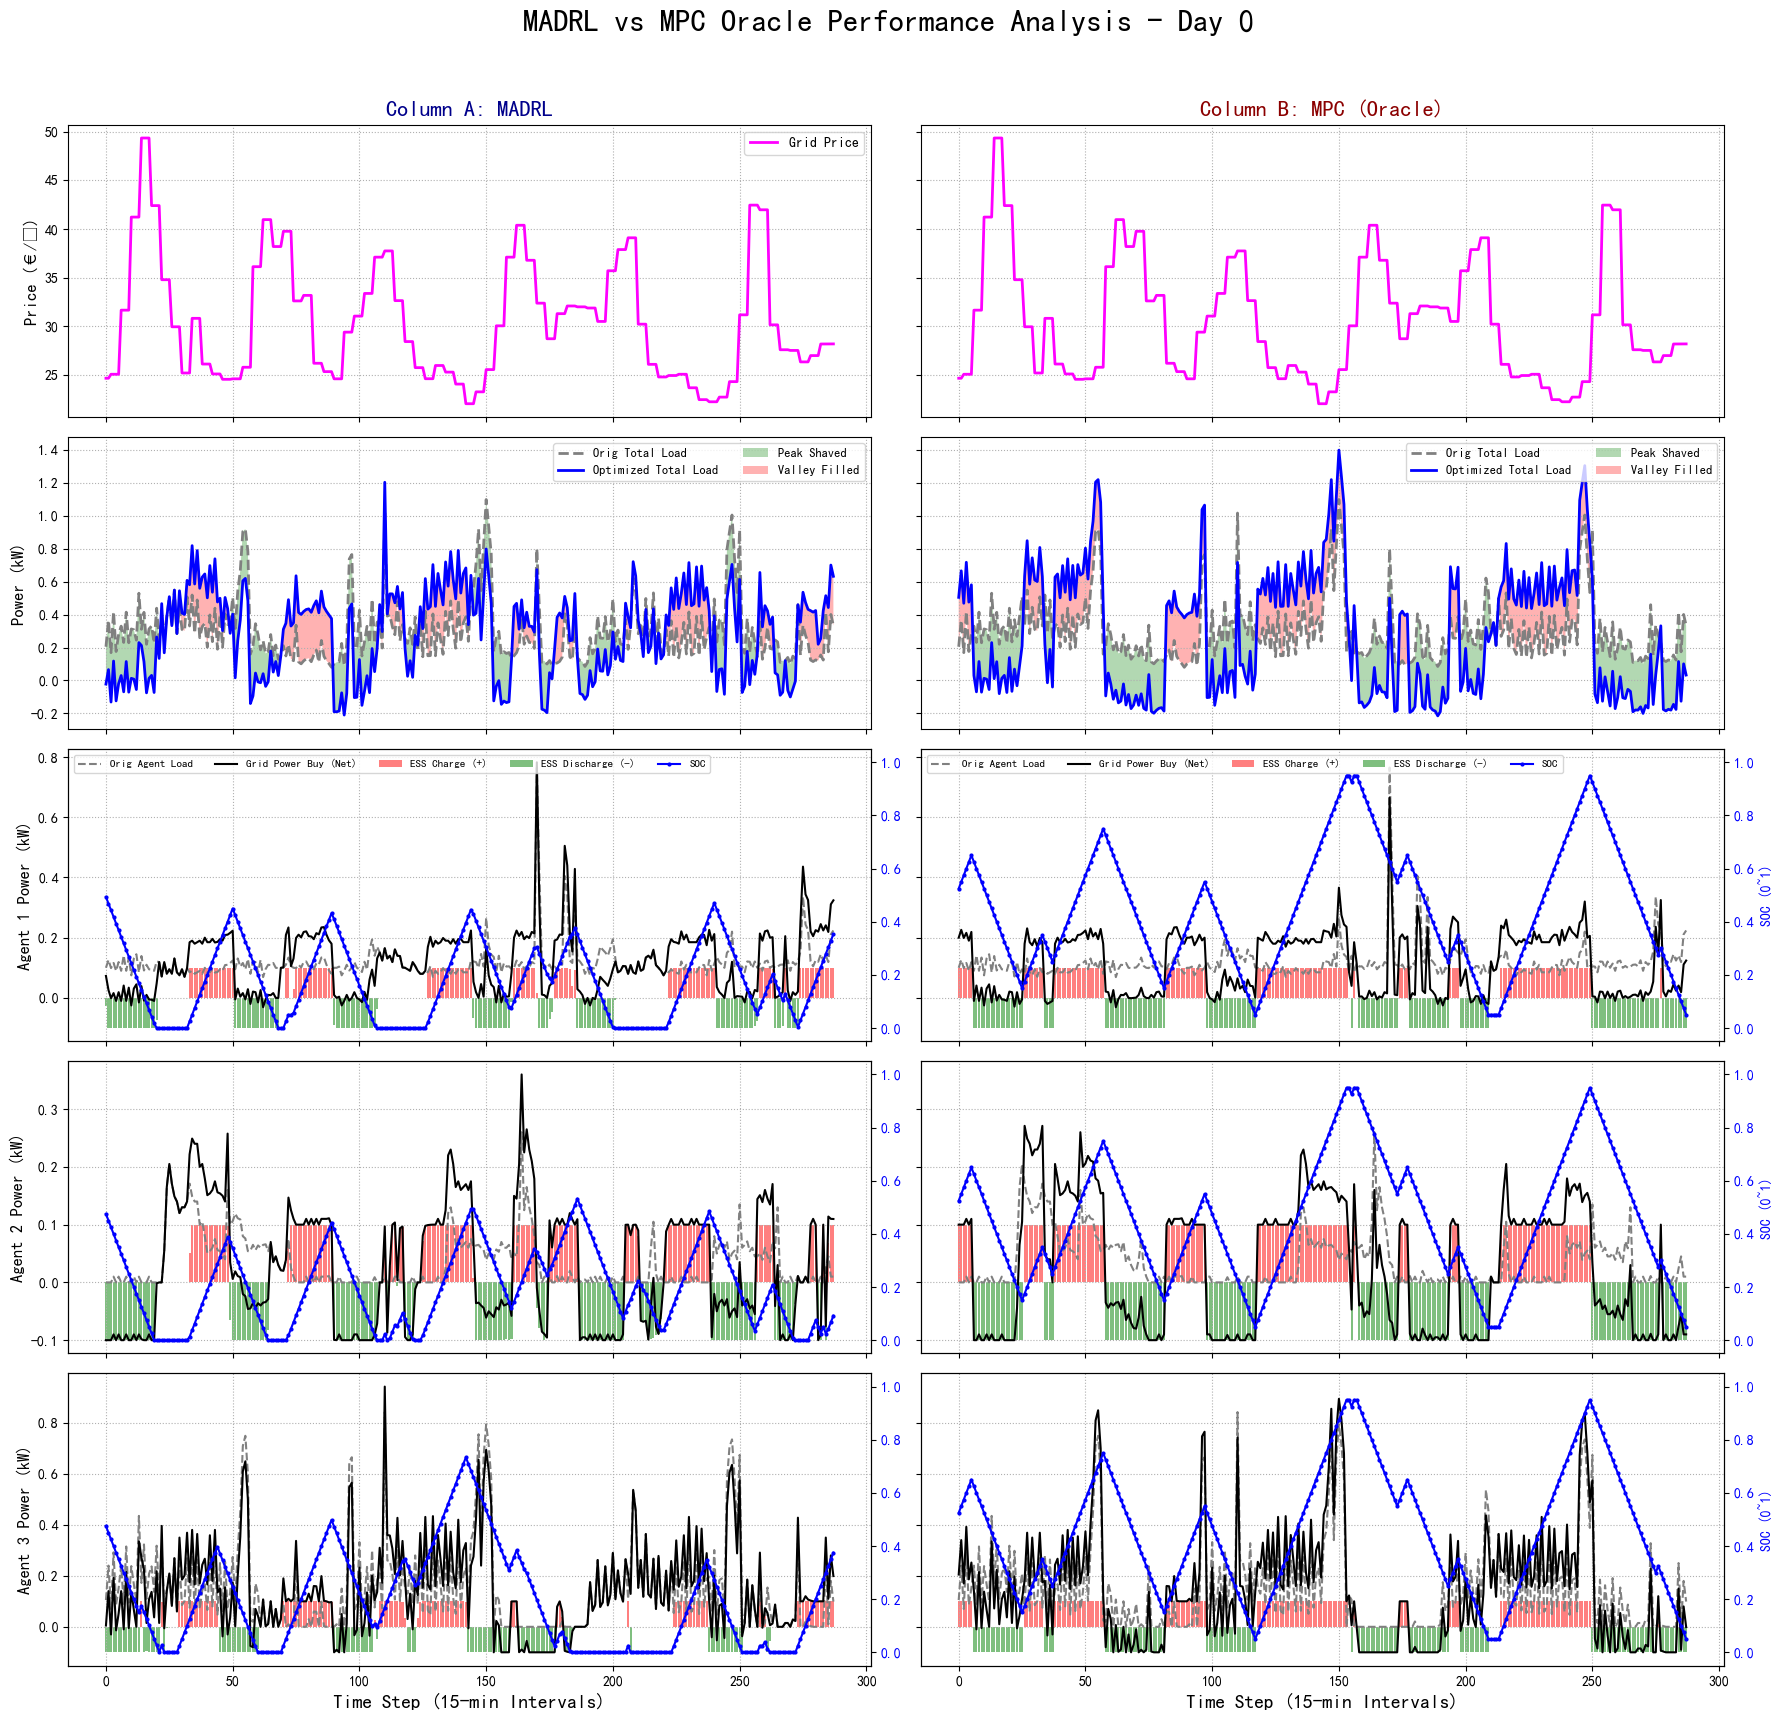

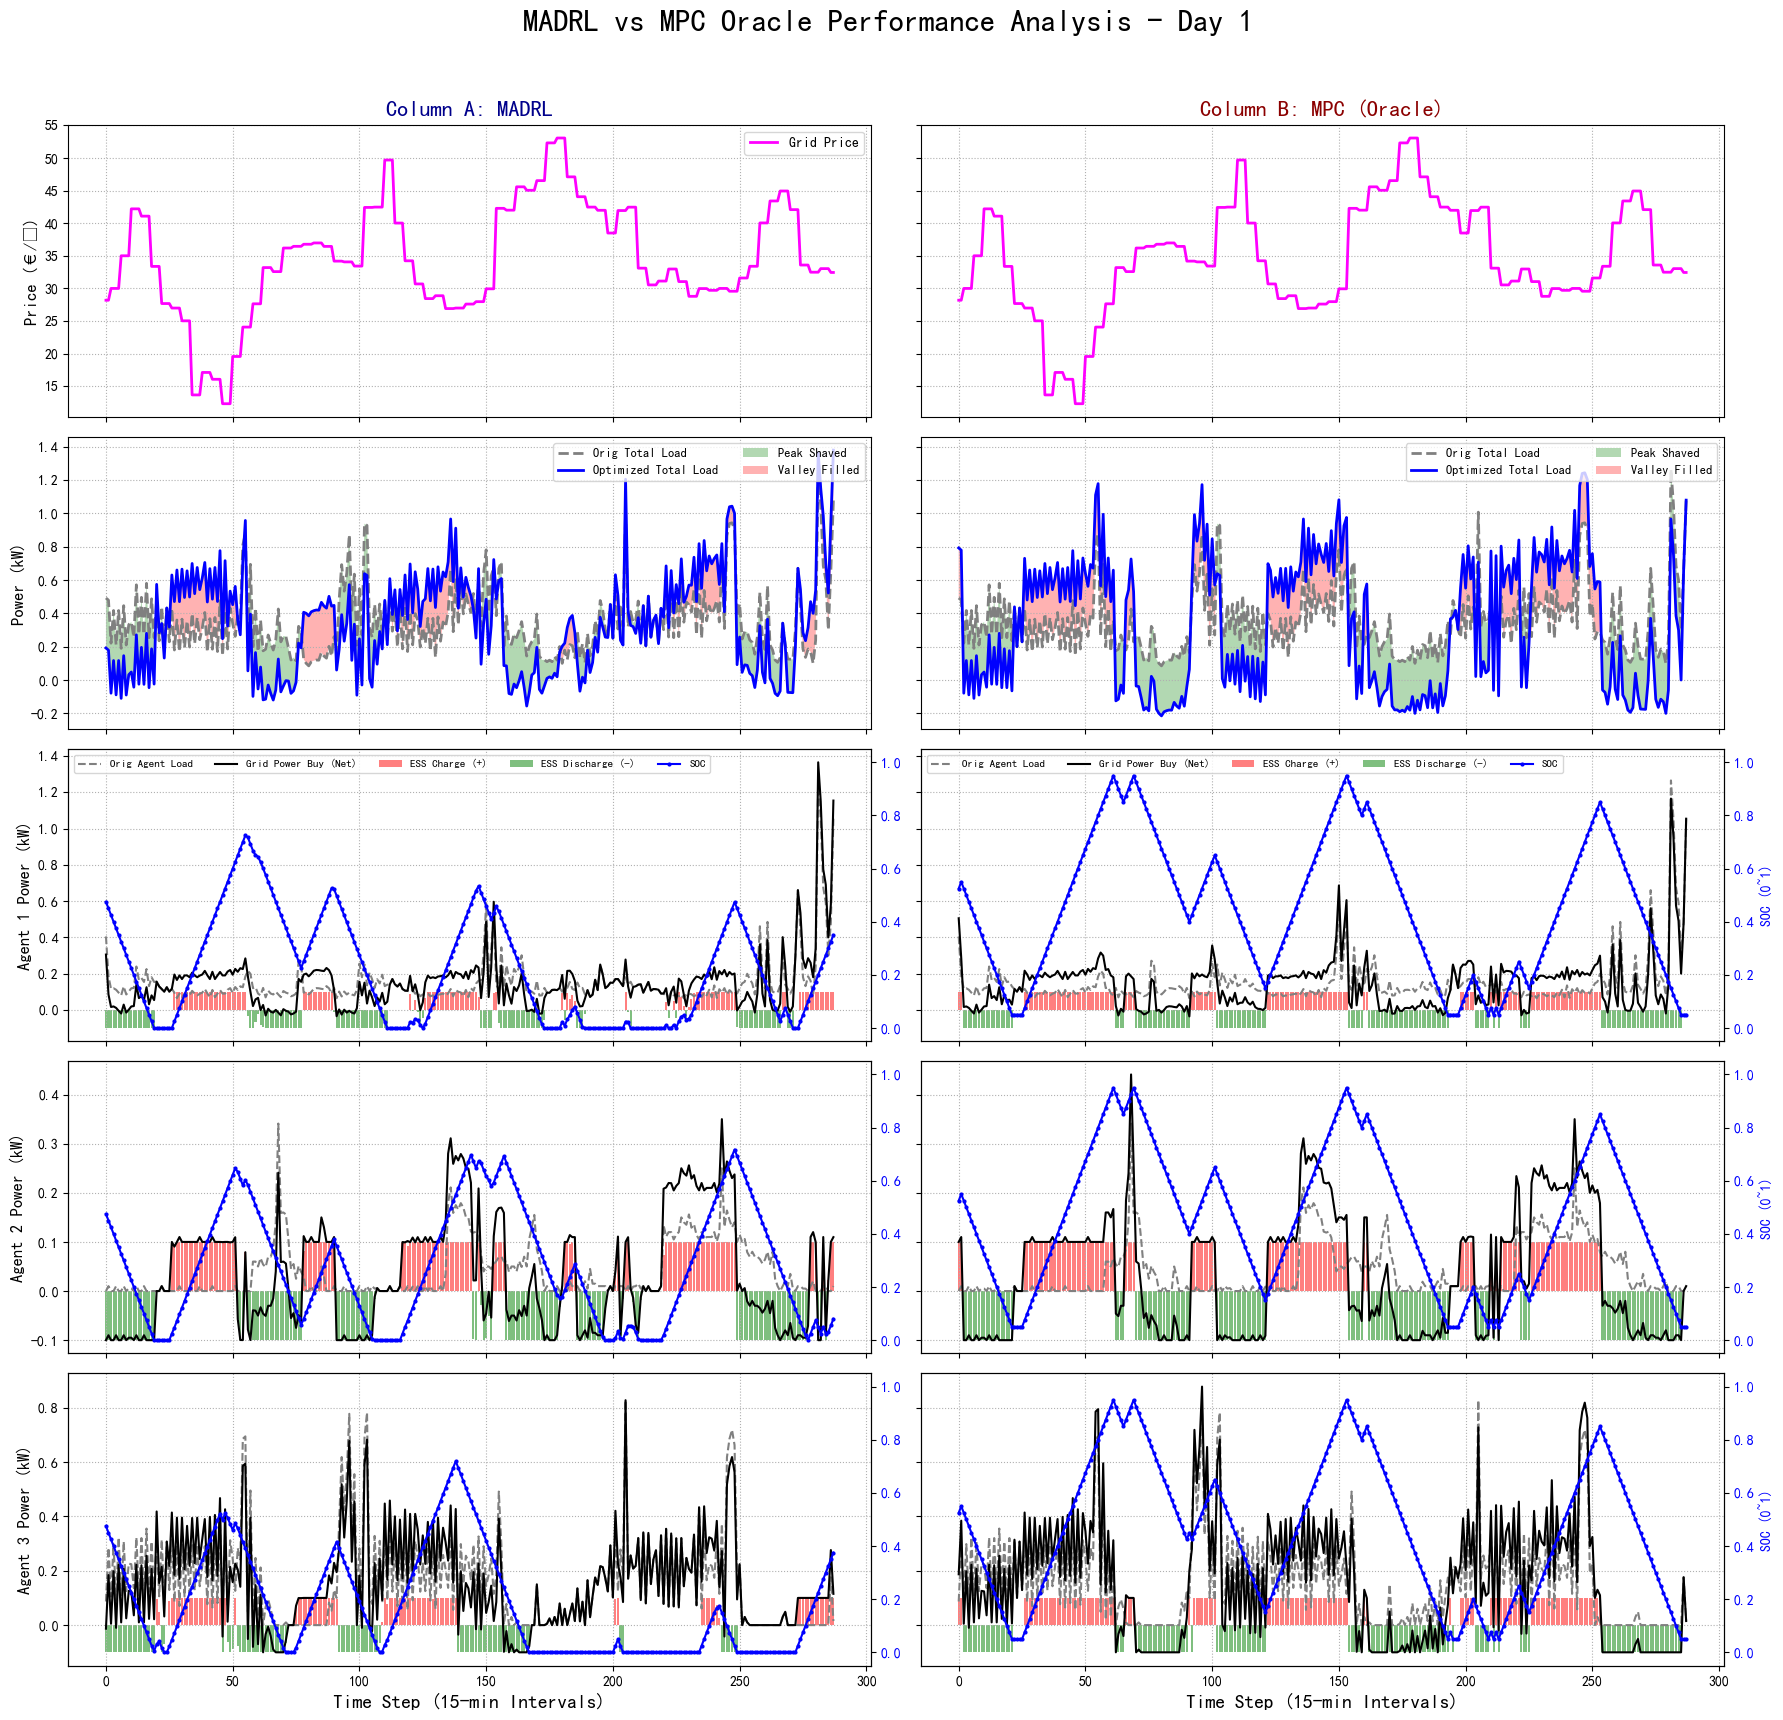

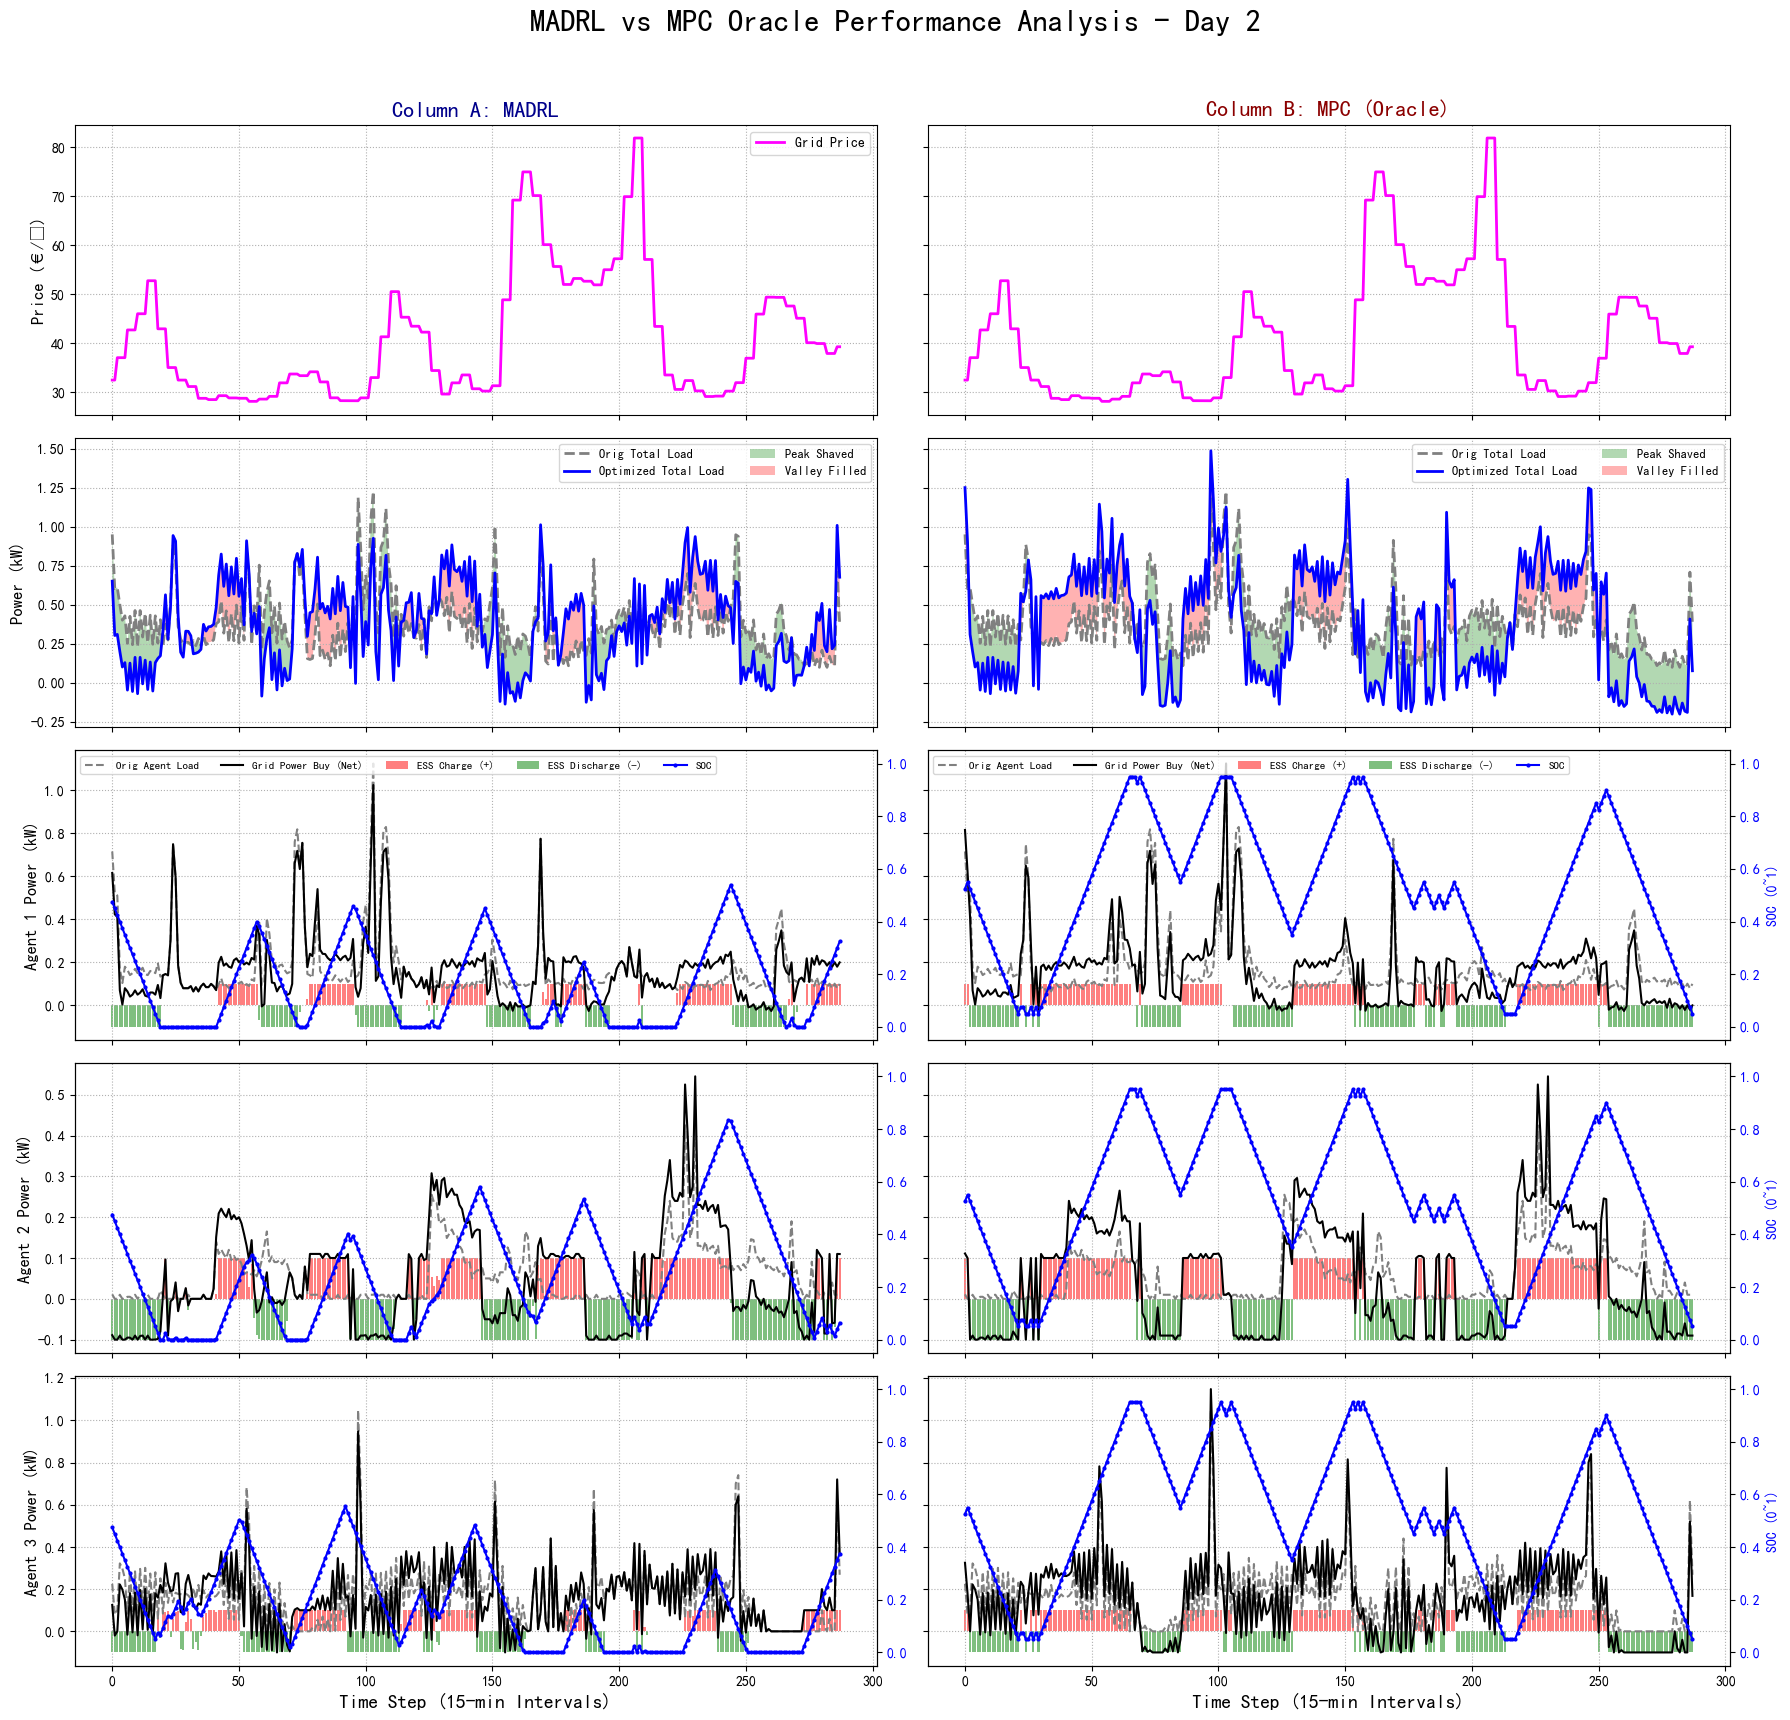

In [4]:
# ==========================================
# Cell 4: 绘制 5*2 大图，对比分析两种方法策略差异
# ==========================================

# 确保图形不中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

DAYS_TO_PLOT = min(3, TEST_DAYS)
time_steps = np.arange(args.episode_limit)

for i_day in range(DAYS_TO_PLOT):
    actual_day_idx = TEST_START_DAY + i_day
    drl_data = drl_test_results[i_day]
    mpc_data = mpc_test_results[i_day]
    
    # 创建 5*2 大图画布
    fig, axs = plt.subplots(5, 2, figsize=(18, 3.5 * 5), sharex='col', sharey='row')
    fig.suptitle(f'MADRL vs MPC Oracle Performance Analysis - Day {actual_day_idx}', fontsize=22, y=0.98)
    
    # 方法名称列标题
    axs[0, 0].set_title('Column A: MADRL', fontsize=16, color='darkblue', fontweight='bold')
    axs[0, 1].set_title('Column B: MPC (Oracle)', fontsize=16, color='darkred', fontweight='bold')

    # ==========================================
    # Column 0: MADRL
    # ==========================================
    
    # Row 0: 电价
    ax_price_drl = axs[0, 0]
    ax_price_drl.plot(time_steps, drl_data['price'], color='magenta', linewidth=2, label='Grid Price')
    ax_price_drl.set_ylabel('Price (€/¥)', fontsize=12)
    ax_price_drl.grid(True, linestyle=':')
    ax_price_drl.legend(loc='upper right')
    
    # Row 1: 总峰谷对比
    ax_load_drl = axs[1, 0]
    ax_load_drl.plot(time_steps, drl_data['orig_load'], color='grey', linestyle='--', linewidth=2, label='Orig Total Load')
    ax_load_drl.plot(time_steps, drl_data['net_load'], color='blue', linewidth=2, label='Optimized Total Load')
    ax_load_drl.set_ylabel('Power (kW)', fontsize=12)
    
    # ★ 隐藏 Bug 修复：将 day_data 全部替换为 drl_data
    ax_load_drl.fill_between(time_steps, drl_data['orig_load'], drl_data['net_load'], 
                         where=(np.array(drl_data['net_load']) < np.array(drl_data['orig_load'])), 
                         facecolor='green', alpha=0.3, interpolate=True, label='Peak Shaved')
    ax_load_drl.fill_between(time_steps, drl_data['orig_load'], drl_data['net_load'], 
                         where=(np.array(drl_data['net_load']) > np.array(drl_data['orig_load'])), 
                         facecolor='red', alpha=0.3, interpolate=True, label='Valley Filled')
    ax_load_drl.grid(True, linestyle=':')
    ax_load_drl.legend(loc='upper right', ncol=2, fontsize=9)
    
    # Row 2~4: 每个 Agent 对应的电力电量平衡
    for ag_id in range(args.N):
        ax_ag = axs[2 + ag_id, 0]
        
        # 提取当前 Agent 的数据
        e_bat_arr = np.array(drl_data['e_bat'][ag_id])
        orig_load_arr = np.array(drl_data['orig_load_agent'][ag_id])
        net_load_arr = np.array(drl_data['net_load_agent'][ag_id])
        soc_arr = np.array(drl_data['soc'][ag_id][1:]) # 末端 SOC
        
        # 1. 绘制个体的电力电量平衡
        ax_ag.plot(time_steps, orig_load_arr, color='grey', linestyle='--', linewidth=1.5, label='Orig Agent Load')
        ax_ag.plot(time_steps, net_load_arr, color='black', linewidth=1.5, label='Grid Power Buy (Net)')
        
        # 2. 绘制储能动作
        ax_ag.bar(time_steps, np.maximum(0, e_bat_arr), color='red', width=0.8, alpha=0.5, label='ESS Charge (+)')
        ax_ag.bar(time_steps, np.minimum(0, e_bat_arr), color='green', width=0.8, alpha=0.5, label='ESS Discharge (-)')
        
        ax_ag.set_ylabel(f'Agent {ag_id+1} Power (kW)', fontsize=12)
        ax_ag.grid(True, axis='both', linestyle=':')
        
        # 3. 绘制 SOC (Twinx)
        ax_soc = ax_ag.twinx()
        ax_soc.plot(time_steps, soc_arr, color='blue', marker='.', markersize=4, linewidth=1.5, label='SOC')
        ax_soc.tick_params(axis='y', labelcolor='blue')
        ax_soc.set_ylim(-0.05, 1.05)
        
        # 合并图例
        if ag_id == 0:
            lines_1, labels_1 = ax_ag.get_legend_handles_labels()
            lines_2, labels_2 = ax_soc.get_legend_handles_labels()
            ax_ag.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', ncol=5, fontsize=8)

    # ==========================================
    # Column 1: MPC Oracle
    # ==========================================
    
    # Row 0: 电价
    ax_price_mpc = axs[0, 1]
    ax_price_mpc.plot(time_steps, mpc_data['price'], color='magenta', linewidth=2)
    ax_price_mpc.grid(True, linestyle=':')
    
    # Row 1: 总峰谷对比
    ax_load_mpc = axs[1, 1]
    ax_load_mpc.plot(time_steps, mpc_data['orig_load'], color='grey', linestyle='--', linewidth=2, label='Orig Total Load')
    ax_load_mpc.plot(time_steps, mpc_data['net_load'], color='blue', linewidth=2, label='Optimized Total Load')
    
    ax_load_mpc.fill_between(time_steps, mpc_data['orig_load'], mpc_data['net_load'], 
                         where=(np.array(mpc_data['net_load']) < np.array(mpc_data['orig_load'])), 
                         facecolor='green', alpha=0.3, interpolate=True, label='Peak Shaved')
    ax_load_mpc.fill_between(time_steps, mpc_data['orig_load'], mpc_data['net_load'], 
                         where=(np.array(mpc_data['net_load']) > np.array(mpc_data['orig_load'])), 
                         facecolor='red', alpha=0.3, interpolate=True, label='Valley Filled')
    ax_load_mpc.grid(True, linestyle=':')
    ax_load_mpc.legend(loc='upper right', ncol=2, fontsize=9)
    
    # Row 2~4: 每个 Agent 对应的电力电量平衡
    for ag_id in range(args.N):
        ax_ag = axs[2 + ag_id, 1]
        
        e_bat_arr = np.array(mpc_data['e_bat'][ag_id])
        orig_load_arr = np.array(mpc_data['orig_load_agent'][ag_id])
        net_load_arr = np.array(mpc_data['net_load_agent'][ag_id])
        soc_arr = np.array(mpc_data['soc'][ag_id][1:]) # 末端 SOC
        
        # 1. 绘制个体的电力电量平衡
        ax_ag.plot(time_steps, orig_load_arr, color='grey', linestyle='--', linewidth=1.5, label='Orig Agent Load')
        ax_ag.plot(time_steps, net_load_arr, color='black', linewidth=1.5, label='Grid Power Buy (Net)')
        
        # 2. 绘制储能动作
        ax_ag.bar(time_steps, np.maximum(0, e_bat_arr), color='red', width=0.8, alpha=0.5, label='ESS Charge (+)')
        ax_ag.bar(time_steps, np.minimum(0, e_bat_arr), color='green', width=0.8, alpha=0.5, label='ESS Discharge (-)')
        
        ax_ag.grid(True, axis='both', linestyle=':')
        
        # 3. 绘制 SOC (Twinx)
        ax_soc = ax_ag.twinx()
        ax_soc.plot(time_steps, soc_arr, color='blue', marker='.', markersize=4, linewidth=1.5, label='SOC')
        ax_soc.set_ylabel('SOC (0~1)', color='blue', fontsize=10)
        ax_soc.tick_params(axis='y', labelcolor='blue')
        ax_soc.set_ylim(-0.05, 1.05)
        
        # ★ 显式 Bug 修复：将 ax_agent 修正为 ax_ag
        if ag_id == 0:
            lines_1, labels_1 = ax_ag.get_legend_handles_labels()
            lines_2, labels_2 = ax_soc.get_legend_handles_labels()
            ax_ag.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', ncol=5, fontsize=8)
            
    # 设置横轴
    axs[-1, 0].set_xlabel('Time Step (15-min Intervals)', fontsize=14)
    axs[-1, 1].set_xlabel('Time Step (15-min Intervals)', fontsize=14)
    
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()